In [5]:
import pandas as pd
import requests

# 1. Collect API Data using exact URL provided
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"
response = requests.get(url)

if response.status_code == 200:
  data = response.json()

  # 2. Convert JSON response to Pandas DataFrame
  df = pd.DataFrame(data["items"])

  # 3. Select Required Columns
  required_cols = [
      "name",
      "owner",
      "language",
      "stargazers_count",
      "forks_count",
      "watchers_count",
      "open_issues_count",
      "created_at",
      "updated_at",
      "license",
  ]
  df_selected = df[required_cols].copy()

  # 4. Extract Required Values from Nested Columns
  df_selected["owner"] = df_selected["owner"].apply(
      lambda x: x["login"] if isinstance(x, dict) else None
  )
  df_selected["license"] = df_selected["license"].apply(
      lambda x: x["name"] if isinstance(x, dict) and x else "No License"
  )

  # 5. Handle Missing Values
  df_selected["language"] = df_selected["language"].fillna("Unknown")

  # 6. Handle Duplicate Records
  df_selected.drop_duplicates(inplace=True)

  # 7. Prepare the Dataset (Convert dates and rename columns)
  df_selected["created_at"] = pd.to_datetime(
      df_selected["created_at"]
  ).dt.date
  df_selected["updated_at"] = pd.to_datetime(
      df_selected["updated_at"]
  ).dt.date

  df_cleaned = df_selected.rename(
      columns={
          "stargazers_count": "stars",
          "forks_count": "forks",
          "watchers_count": "watchers",
          "open_issues_count": "open_issues",
          "created_at": "created_date",
          "updated_at": "updated_date",
      }
  )

  # 8. Save & Verify Dataset
  df_cleaned.to_csv("github_projects.csv", index=False)
  print("✅ Task 1 Completed: Saved as github_projects.csv")

  # Verification reload
  verify_df = pd.read_csv("github_projects.csv")
  display(verify_df.head(5))
else:
  print("❌ API Error:", response.status_code)

✅ Task 1 Completed: Saved as github_projects.csv


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197029,76029,197029,2846,2015-11-07,2026-08-15,Apache License 2.0
1,transformers,huggingface,Python,164103,34249,164103,2385,2018-10-29,2026-08-15,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89398,21939,89398,11,2021-03-03,2026-08-15,MIT License
3,funNLP,fighting41love,Python,82471,15268,82471,53,2018-08-21,2026-08-15,No License
4,awesome-machine-learning,josephmisiti,Python,74037,15613,74037,24,2014-07-15,2026-08-15,Other


In [6]:
import sqlite3

# 1. Create SQLite Database & Store Dataset
conn = sqlite3.connect("github_data.db")
df_cleaned.to_sql("Repositories", conn, if_exists="replace", index=False)

print("--- Step 2: Filtering & Searching Queries ---")
# Query A: Filter repositories with more than 10,000 stars
q1 = "SELECT name, owner, stars, language FROM Repositories WHERE stars > 10000 LIMIT 5;"
display(pd.read_sql_query(q1, conn))

# Query B: Repositories whose names contain "Machine"
q2 = "SELECT name, owner, stars FROM Repositories WHERE name LIKE '%Machine%' LIMIT 5;"
display(pd.read_sql_query(q2, conn))

print("\n--- Step 3: Logical Operators (AND, OR, NOT) ---")
# Query 1 using AND / NOT
q3 = "SELECT name, language, stars FROM Repositories WHERE stars > 15000 AND NOT language = 'Python' LIMIT 5;"
display(pd.read_sql_query(q3, conn))

# Query 2 using OR / AND
q4 = "SELECT name, language, stars FROM Repositories WHERE (language = 'Python' OR language = 'C++') AND stars > 20000 LIMIT 5;"
display(pd.read_sql_query(q4, conn))

print("\n--- Step 4: Sorting & Top 10 Repositories ---")
q5 = "SELECT name, owner, stars, language FROM Repositories ORDER BY stars DESC LIMIT 10;"
top_10_df = pd.read_sql_query(q5, conn)
display(top_10_df)

print("\n--- Step 5: Aggregate Functions ---")
q6 = "SELECT COUNT(*) AS total_repositories, AVG(stars) AS average_stars FROM Repositories;"
display(pd.read_sql_query(q6, conn))

print("\n--- Step 6: Grouping Analysis (Languages with > 5 Repositories) ---")
q7 = """
SELECT language, COUNT(*) AS repo_count, AVG(stars) AS avg_stars
FROM Repositories
WHERE language != 'Unknown'
GROUP BY language
HAVING repo_count > 5
ORDER BY repo_count DESC;
"""
display(pd.read_sql_query(q7, conn))

--- Step 2: Filtering & Searching Queries ---


,name,owner,stars,language
0,tensorflow,tensorflow,197029,C++
1,transformers,huggingface,164103,Python
2,ML-For-Beginners,microsoft,89398,Jupyter Notebook
3,funNLP,fighting41love,82471,Python
4,awesome-machine-learning,josephmisiti,74037,Python


,name,owner,stars
0,awesome-machine-learning,josephmisiti,74037
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36273
2,machine-learning-for-software-engineers,ZuzooVn,28857
3,homemade-machine-learning,trekhleb,24755
4,awesome-production-machine-learning,EthicalML,20846



--- Step 3: Logical Operators (AND, OR, NOT) ---


,name,language,stars
0,tensorflow,C++,197029
1,ML-For-Beginners,Jupyter Notebook,89398
2,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36273
3,C-Plus-Plus,C++,34583
4,netron,JavaScript,33353


...

,name,owner,stars,language
0,tensorflow,tensorflow,197029,C++
1,transformers,huggingface,164103,Python
2,ML-For-Beginners,microsoft,89398,Jupyter Notebook
3,funNLP,fighting41love,82471,Python
4,awesome-machine-learning,josephmisiti,74037,Python
5,scikit-learn,scikit-learn,66955,Python
6,gradio,gradio-app,43366,Python
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36273,Unknown
8,C-Plus-Plus,TheAlgorithms,34583,C++
9,netron,lutzroeder,33353,JavaScript



--- Step 5: Aggregate Functions ---


,total_repositories,average_stars
0,100,20789.12



--- Step 6: Grouping Analysis (Languages with > 5 Repositories) ---


,language,repo_count,avg_stars
0,Python,30,26538.500000
1,Jupyter Notebook,19,17034.368421
2,C++,12,32171.500000


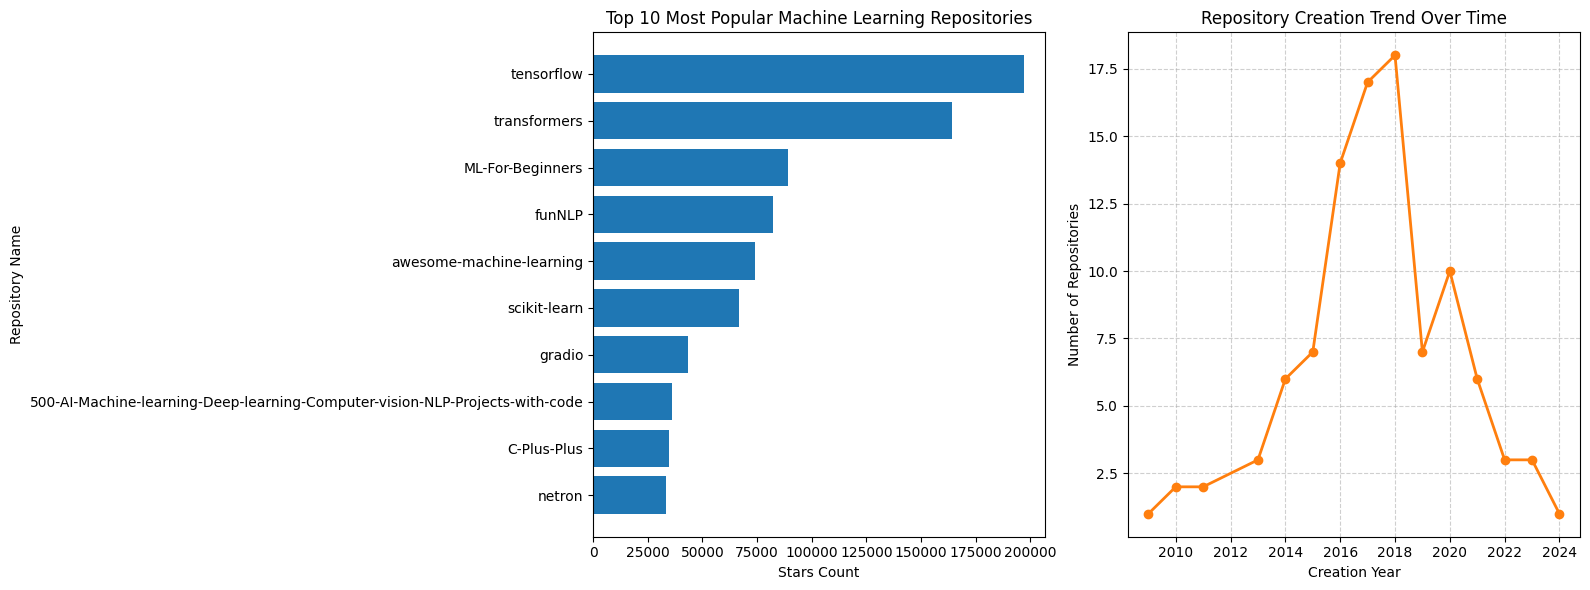

In [7]:
import matplotlib.pyplot as plt

# Step 7: Create Python Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualization 1: Top 10 Repositories by Stars
axes[0].barh(top_10_df["name"], top_10_df["stars"], color="#1f77b4")
axes[0].set_xlabel("Stars Count")
axes[0].set_ylabel("Repository Name")
axes[0].set_title("Top 10 Most Popular Machine Learning Repositories")
axes[0].invert_yaxis()

# Visualization 2: Yearly Repository Creation Trend
df_cleaned["created_year"] = pd.to_datetime(
    df_cleaned["created_date"]
).dt.year
yearly_counts = (
    df_cleaned["created_year"].value_counts().sort_index().reset_index()
)
yearly_counts.columns = ["year", "count"]

axes[1].plot(
    yearly_counts["year"],
    yearly_counts["count"],
    marker="o",
    linewidth=2,
    color="#ff7f0e",
)
axes[1].set_xlabel("Creation Year")
axes[1].set_ylabel("Number of Repositories")
axes[1].set_title("Repository Creation Trend Over Time")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

conn.close()

In [13]:
!git config --global user.email "your_email@example.com"
!git config --global user.name "Your Name"

!git init
!git add .
!git commit -m "Initial commit: Completed GitHub Data Analytics Pipeline"
!git branch -M main

!git remote remove origin

!git remote add origin https://my_GITHUB_TOKEN@github.com/abdulrahman22-code/GitHub-data-analytics-pipeline.git

!git push -u origin main

Reinitialized existing Git repository in /content/.git/
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Password for 'https://my_GITHUB_TOKEN@github.com': No such device or address
